# Heart Disease Risk Prediction with Logistic Regression
## Mariana Malagón
### Step 1: Load and Prepare the Dataset

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [34]:
df.duplicated().sum()

723

 Handling duplicate records: The raw dataset contained 1025 rows but only 302 unique patient records, the remaining 723 rows were exact duplicates, likely produced by repeating the original 303-row UCI Cleveland dataset. Duplicates were removed prior to any further processing to prevent the same patient from appearing in both the training and test sets, which would artificially inflate performance metrics (data leakage).


In [35]:
df = df.drop_duplicates()
df.shape

(302, 14)

In [36]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [37]:
df['ca'].value_counts()

0    175
1     65
2     38
3     20
4      4
Name: ca, dtype: int64

In [38]:
df['thal'].value_counts()

2    165
3    117
1     18
0      2
Name: thal, dtype: int64

Handling disguised missing values: The ca (number of major vessels) and thal (thalassemia test result) columns contained values outside their documented valid ranges ca =  (valid range: 0–3) and thal = 0 (valid range: 1–3). These are known placeholder codes used in the original UCI dataset to represent missing measurements, not genuine clinical categories. Since they affected only 6 of 302 records, these rows were removed rather than imputed, avoiding the introduction of misleading patterns into the model while preserving the vast majority of the data.


In [39]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)]
df.shape

(296, 14)

### Plot the class distribution.

In [40]:
df['target'].value_counts()

1    160
0    136
Name: target, dtype: int64

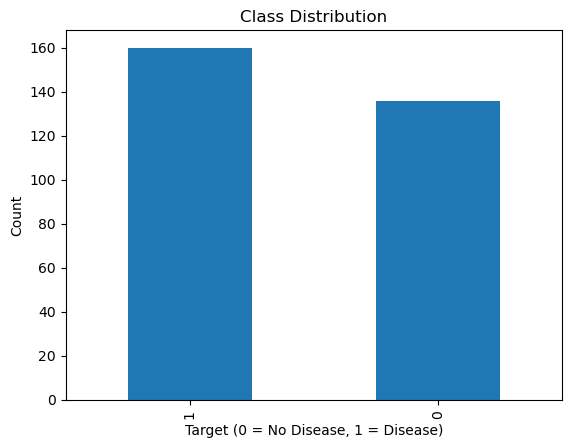

In [41]:
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

 Class distribution: After cleaning, the dataset contains 296 patients: 160 with heart disease (54%) and 136 without (46%). The classes are reasonably balanced, so no resampling or class-weighting techniques are needed before training.


Prepare a stratified 70/30 train/test split and normalize numerical features and Select at least six features, such as age, cholesterol, blood pressure, maximum heart rate, ST depression, and number of vessels

 Now to divide the dataset in 70/30 maintaining the 54/46 I´m going to use the following function:

In [42]:
np.random.seed(42)

def split_class(df_class, train_frac=0.7):
    n = len(df_class)
    shuffled_idx = np.random.permutation(n)   
    cutoff = int(n * train_frac)
    train_idx = shuffled_idx[:cutoff]
    test_idx = shuffled_idx[cutoff:]
    return df_class.iloc[train_idx], df_class.iloc[test_idx]

df_0 = df[df['target'] == 0]
df_1 = df[df['target'] == 1]

train_0, test_0 = split_class(df_0)
train_1, test_1 = split_class(df_1)

train_df = pd.concat([train_0, train_1])
test_df = pd.concat([test_0, test_1])

print(train_df.shape, test_df.shape)
print(train_df['target'].value_counts(normalize=True))
print(test_df['target'].value_counts(normalize=True))


(207, 14) (89, 14)
1    0.541063
0    0.458937
Name: target, dtype: float64
1    0.539326
0    0.460674
Name: target, dtype: float64


Train/test split: A manual stratified 70/30 split was implemented by splitting each class independently before recombining, guaranteeing that both subsets preserve the original class proportions. The resulting train set (207 samples) has a 54.1%/45.9% class balance, and the test set (89 samples) has 53.9%/46.1%, both closely matching the full dataset's 54%/46% distribution.


#### Now the six features selected

In [43]:
features = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']

In [44]:
X_train = train_df[features].values
y_train = train_df['target'].values
X_test = test_df[features].values
y_test = test_df['target'].values

X_train.shape, X_test.shape

((207, 6), (89, 6))

Feature normalization: The selected features have very different scales (for example chol ranges from 126 to 564, while ca ranges from 0 to 3). Without normalization, gradient descent would need a very small learning rate to avoid diverging on large-scale features like chol, which would make convergence on small-scale features like ca extremely slow.


In [45]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

X_train_norm[:5]

array([[ 0.12299367,  0.7422416 ,  3.82283602, -0.74830258,  2.4619743 ,
         1.35484923],
       [-0.21798431,  0.62644408, -0.51304837, -2.42240614,  0.78776707,
         1.35484923],
       [ 0.23665299,  0.47204739,  1.11994705, -2.73079364,  0.11808418,
         0.30837986],
       [ 0.46397164, -0.01044229,  2.35877116, -0.30774901, -0.88644016,
        -0.73808951],
       [ 0.00933434, -0.85962412, -0.23149744, -0.88046865,  0.78776707,
         0.30837986]])

## Step 2: Implement Basic Logistic Regression

This function is the sigmoid activation. It takes the linear score z and squashes it into a probability between 0 and 1 so it can be interpreted as the chance that a patient has heart disease. I added a clip on z so that very large or very negative values do not cause overflow errors when computing the exponential.

In [46]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

This function calculates the cost of the model for a given set of weights, using binary cross entropy. It measures how far the predicted probabilities are from the real labels across all training examples, and this is the value that gradient descent will try to minimize. I clipped the predicted probabilities before taking the logarithm to avoid a log of zero error.

In [47]:
def compute_cost(w, b, X, y):
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)
    
    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    return J

In [48]:
w_test = np.zeros(X_train_norm.shape[1])
b_test = 0.0
compute_cost(w_test, b_test, X_train_norm, y_train)

0.6931471805599452

Sanity check: With w=0 and b=0, the model predicts 0.5 for every patient, so the cost should equal -log(0.5) ≈ 0.693, which matches the result, confirming compute_cost works correctly.



This function computes the gradient of the cost function with respect to w and b, which tells us the direction and speed we need to move the parameters in order to reduce the cost. It is based on the difference between the predicted probability and the true label for every patient, averaged across the training set.

In [49]:
def compute_gradient(w, b, X, y):
    m, n = X.shape
    
    z = X @ w + b
    f = sigmoid(z)
    
    error = f - y
    
    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)
    
    return dj_dw, dj_db

This function puts everything together and actually trains the model. It starts from the initial weights and bias, and on every iteration it uses compute_gradient to know how to update w and b, then records the cost with compute_cost so I can check later that the model is learning correctly.

In [50]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history

In [51]:
n_features = X_train_norm.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

alpha = 0.01
num_iters = 1000

w_final, b_final, J_history = gradient_descent(
    X_train_norm, y_train, w_init, b_init, alpha, num_iters, print_every=100
)

Iteration    0: J(w, b) = 0.6913
Iteration  100: J(w, b) = 0.5725
Iteration  200: J(w, b) = 0.5216
Iteration  300: J(w, b) = 0.4954
Iteration  400: J(w, b) = 0.4800
Iteration  500: J(w, b) = 0.4701
Iteration  600: J(w, b) = 0.4631
Iteration  700: J(w, b) = 0.4581
Iteration  800: J(w, b) = 0.4543
Iteration  900: J(w, b) = 0.4513
Iteration  999: J(w, b) = 0.4489


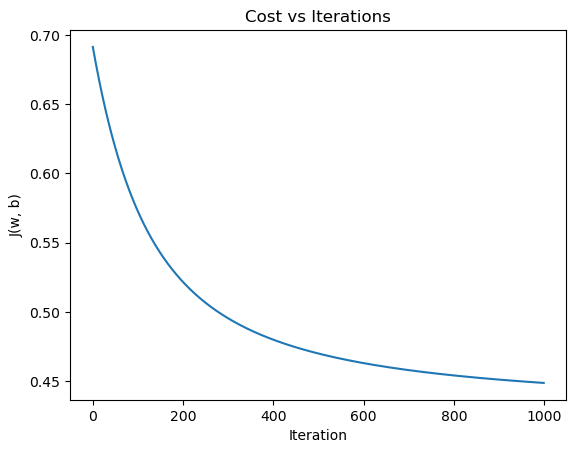

In [52]:
plt.figure()
plt.plot(J_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

Convergence: The cost decreased steadily from 0.693 to 0.449 over 1000 iterations, with the largest drops happening early on and the curve flattening out afterward, indicating the model converged to a stable minimum without diverging or oscillating.

The first function turns the probabilities the model outputs into actual class predictions using a threshold of 0.5. The second function takes those predictions and compares them with the real labels to calculate accuracy, precision, recall and F1, which are the metrics I need to know how well the model is really performing.

In [53]:
def predict(w, b, X, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

In [54]:
y_train_pred = predict(w_final, b_final, X_train_norm)
y_test_pred = predict(w_final, b_final, X_test_norm)

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)

print(f"Train: Accuracy: {train_metrics[0]:.3f}, Precision: {train_metrics[1]:.3f}, Recall: {train_metrics[2]:.3f}, F1: {train_metrics[3]:.3f}")
print(f"Test: Accuracy: {test_metrics[0]:.3f}, Precision: {test_metrics[1]:.3f}, Recall: {test_metrics[2]:.3f}, F1: {test_metrics[3]:.3f}")

Train: Accuracy: 0.787, Precision: 0.770, Recall: 0.866, F1: 0.815
Test: Accuracy: 0.742, Precision: 0.745, Recall: 0.792, F1: 0.768


| Set   | Accuracy | Precision | Recall | F1    |
|-------|----------|-----------|--------|-------|
| Train | 0.787    | 0.770     | 0.866  | 0.815 |
| Test  | 0.742    | 0.745     | 0.792  | 0.768 |


In [55]:
for name, weight in zip(features, w_final):
    print(f"{name}: {weight:.3f}")
print(f"bias: {b_final:.3f}")

age: -0.027
chol: -0.121
trestbps: -0.225
thalach: 0.698
oldpeak: -0.578
ca: -0.808
bias: 0.114


Coefficient interpretation: Since all features were standardized (z-score), the magnitude of each weight is directly comparable. The strongest predictors were ca (-0.808),thalach (+0.698), and oldpeak (-0.578); age had almost no effect (-0.027). Notably, the signs for thalach, oldpeak, and ca are opposite to standard clinical expectation (higher ca/oldpeak and lower thalach typically indicate more severe heart disease). This pattern holds even in simple univariate correlations with target, ruling out multicollinearity as the cause. This suggests a possible target-encoding ambiguity in this specific Kaggle CSV, a known issue reported for this dataset, a limitation worth flagging rather than an implementation error.
